# EDA - Análisis Exploratorio de Fraude
## ICBC Prevención de Fraudes

Este notebook analiza el comportamiento de las transacciones evaluadas por el motor de riesgo.
El objetivo es identificar patrones, distribuciones y anomalías que justifican las reglas de detección implementadas.

**Herramientas:** Python · Pandas · Matplotlib · SQLAlchemy · SQL Server

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import urllib
from sqlalchemy import create_engine

# Conexión a SQL Server
SERVER   = r'gustiga123\SQLEXPRESS'
DATABASE = 'ICBC_Fraude'

params = urllib.parse.quote_plus(
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)
engine = create_engine(f'mssql+pyodbc:///?odbc_connect={params}')
print('Conexión establecida.')

Conexión establecida.


## 1. Carga de datos desde SQL Server

Se extraen los datos directamente desde el modelo físico de `ICBC_Fraude` - 
la tabla de hechos `fact_transacciones` ya procesada por el motor de riesgo 
y la dimensión `dim_perfil_usuarios_historico` con los perfiles de comportamiento histórico.

Este enfoque replica el flujo de trabajo real de un equipo de Prevención de Fraudes: 
el analista consulta las vistas y tablas del data warehouse en lugar de trabajar 
con archivos planos, garantizando que el análisis siempre refleja el estado actual 
de la base operativa.

In [3]:
with engine.connect() as conn:
    tx = pd.read_sql('SELECT * FROM dbo.fact_transacciones', conn)
    usuarios = pd.read_sql('SELECT * FROM dbo.dim_perfil_usuarios_historico', conn)

tx['fecha_hora'] = pd.to_datetime(tx['fecha_hora'])
print(f'Transacciones cargadas: {len(tx):,}')
print(f'Usuarios cargados:      {len(usuarios):,}')
tx.head()

Transacciones cargadas: 5,000
Usuarios cargados:      199


,id_transaccion,fecha_hora,id_usuario,canal,monto,id_dispositivo,id_comercio,pais_origen,score_riesgo,decision,reglas_activadas,es_fraude_confirmado,fecha_carga
0,0001cc6e-78f0-4d38-8fef-c3d3d7d08a4d,2026-05-25 18:40:28,USR70648,DEBIN,62753.64,b87d9791-63b2-4671-8,COM2096,AR,0,APPROVE,NaN,False,2026-06-18 13:08:12.186666
1,00106d02-db17-441e-8754-9cd5b40de6b4,2026-03-25 07:59:15,USR18285,DEBIN,63155.84,7e8f184a-58fc-4df3-8,COM2319,AR,0,APPROVE,NaN,False,2026-06-18 13:08:12.673333
2,00140360-86e7-45f8-95aa-45915aba4ad9,2026-06-12 20:33:00,USR77154,TARJETA,42129.68,d2c91052-5c03-4b4f-8,COM7141,AR,0,APPROVE,NaN,False,2026-06-18 13:08:11.560000
3,00232cb8-beb4-43e6-a7a3-f0c92245e054,2026-04-25 04:26:27,USR99764,TRANSFERENCIA,61805.81,664f9fe5-16d9-4b47-9,COM2417,VE,85,DECLINE,"R001,R004",False,2026-06-18 13:08:13.166666
4,004ee07c-1031-4f5d-916c-37881f7abdf2,2026-06-04 14:36:25,USR62513,TRANSFERENCIA,29563.09,c14c77c9-2522-4fbb-9,COM9494,AR,0,APPROVE,NaN,False,2026-06-18 13:08:11.560000


## 2. Distribución de decisiones del motor de riesgo

Una vez ejecutado el motor sobre las 5.000 transacciones, el primer análisis 
obligatorio es entender cómo se distribuyeron las decisiones, es decir, qué proporción 
fue aprobada sin intervención, cuántas quedaron en revisión manual y cuántas 
fueron bloqueadas de forma preventiva.

Esta distribución es el KPI de calibración del motor - si el porcentaje de 
DECLINE es demasiado alto, el motor es agresivo y genera fricción innecesaria 
para clientes legítimos. Si es demasiado bajo, estamos dejando pasar fraude. 
Lo que buscamos como analista de Prevención de Fraudes es un equilibrio entre ambos extremos.

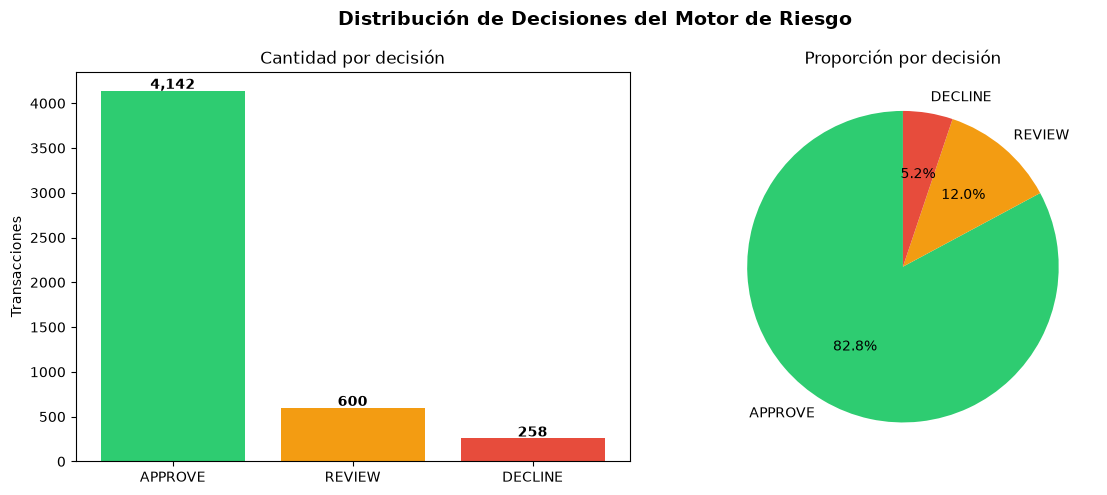

Gráfico guardado en docs/


In [4]:
decision_counts = tx['decision'].value_counts()
colores = {'APPROVE': '#2ecc71', 'REVIEW': '#f39c12', 'DECLINE': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de Decisiones del Motor de Riesgo', fontsize=14, fontweight='bold')

# Barras
bars = axes[0].bar(
    decision_counts.index,
    decision_counts.values,
    color=[colores[d] for d in decision_counts.index]
)
axes[0].set_title('Cantidad por decisión')
axes[0].set_ylabel('Transacciones')
for bar, val in zip(bars, decision_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontweight='bold')

# Torta
axes[1].pie(
    decision_counts.values,
    labels=decision_counts.index,
    colors=[colores[d] for d in decision_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporción por decisión')

plt.tight_layout()
plt.savefig('../docs/distribucion_decisiones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado en docs/')

### Hallazgo

La distribución resultante muestra un motor bien calibrado para una primera versión: 
el 82.8% de las transacciones fue aprobado sin intervención humana, lo que garantiza 
una experiencia fluida para la mayoría de los clientes legítimos.

El 12% en estado REVIEW representa la cola de trabajo diario del equipo de Prevención 
de Fraudes - 600 transacciones que requieren revisión manual antes de ser liberadas o bloqueadas definitivamente. Este volumen es manejable para un equipo operativo y evita saturar la cola con falsas alarmas.

El 5.2% de DECLINE (258 transacciones) representa el bloqueo automático preventivo. 
Es una tasa conservadora que minimiza la fricción con clientes legítimos, 
aunque en producción se ajustaría iterativamente en función de los falsos positivos 
confirmados por el equipo de analistas.

## 3. Distribución de montos: Fraude vs Legítimo

Una de las primeras hipótesis como analista de fraude es validar 
si los montos de las transacciones fraudulentas se comportan de forma diferente 
a las legítimas. En la práctica bancaria, el fraude tiende a concentrarse en montos 
extremos - ya sea muy altos para maximizar el daño, o muy bajos para pasar 
desapercibidos en un primer filtro.

Este histograma superpuesto nos permite visualizar esa separación y confirmar 
si nuestro generador de datos sintéticos replicó correctamente ese comportamiento, 
que es justamente lo que justifica la regla R001 y R005 del motor.

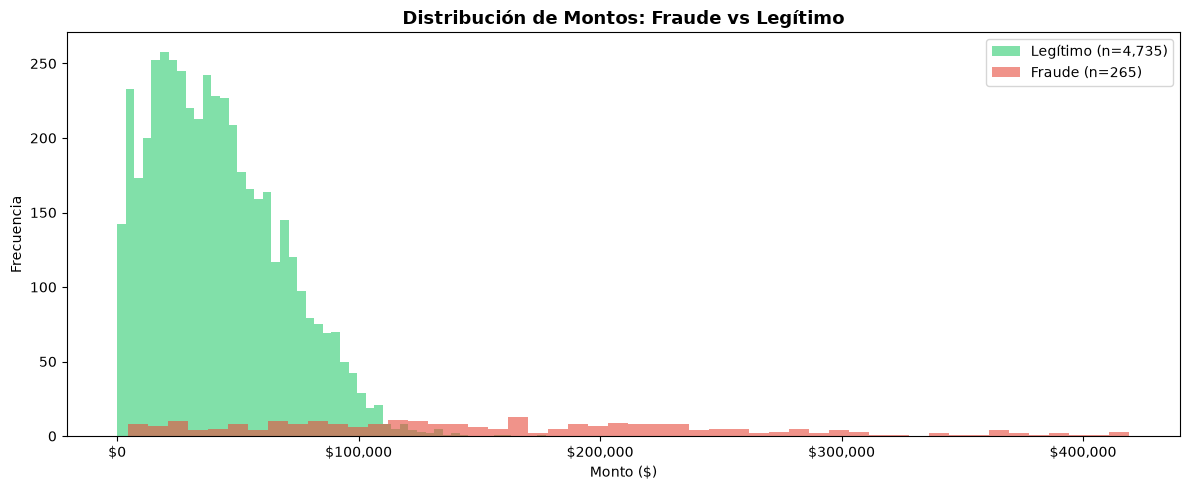

In [5]:
fraude = tx[tx['es_fraude_confirmado'] == 1]['monto']
legitimo = tx[tx['es_fraude_confirmado'] == 0]['monto']

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(legitimo, bins=50, alpha=0.6, color='#2ecc71', label=f'Legítimo (n={len(legitimo):,})')
ax.hist(fraude,   bins=50, alpha=0.6, color='#e74c3c', label=f'Fraude (n={len(fraude):,})')
ax.set_title('Distribución de Montos: Fraude vs Legítimo', fontsize=13, fontweight='bold')
ax.set_xlabel('Monto ($)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('../docs/distribucion_montos.png', dpi=150, bbox_inches='tight')
plt.show()

### Hallazgo

El histograma confirma la hipótesis inicial: las transacciones fraudulentas 
se concentran en montos significativamente más altos que las legítimas. 
Mientras el grueso de las operaciones legítimas se agrupa por debajo de los $100.000, 
el fraude se distribuye de forma más uniforme hacia la cola derecha, 
llegando a superar los $400.000.

Esto valida estadísticamente las reglas **R001** (monto superior al percentil 95 histórico) 
y **R005** (monto superior a 4 veces el promedio del usuario) como señales de riesgo 
relevantes para este tipo de transacciones. En la práctica, este patrón es consistente 
con fraudes de tarjeta clonada donde el atacante intenta maximizar el monto 
antes de que el cliente reporte el incidente.

## 4. Fraude por canal de pago

No todos los canales de pago tienen el mismo perfil de riesgo. En el ecosistema 
financiero argentino, las transferencias inmediatas y el DEBIN son históricamente 
los canales más vulnerables al fraude - en parte por su carácter irrevocable: 
una vez ejecutada la operación, recuperar los fondos es extremadamente difícil.

Este análisis desagrega la tasa de fraude por canal para identificar dónde 
el motor debe ser más estricto y dónde puede ser más permisivo sin aumentar 
el riesgo operativo.

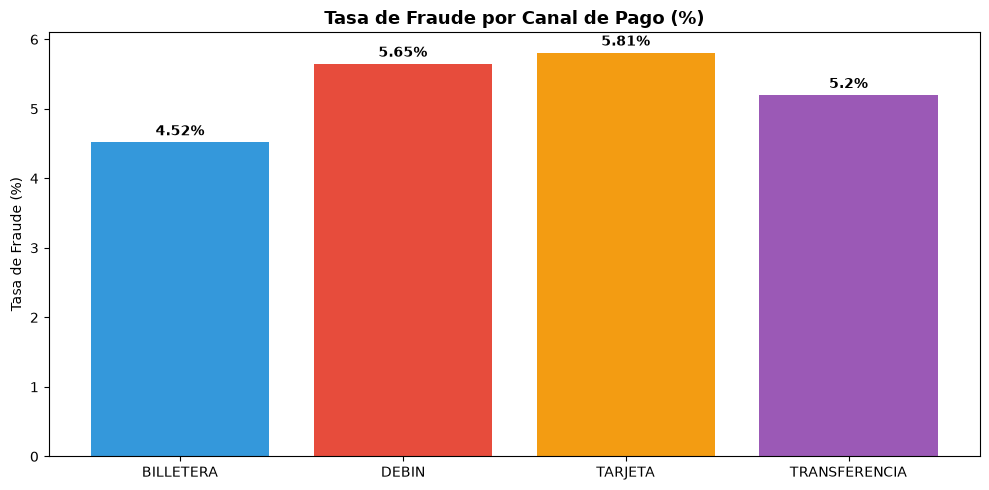

        canal  total  fraudes  tasa_fraude
    BILLETERA   1218       55         4.52
        DEBIN   1257       71         5.65
      TARJETA   1256       73         5.81
TRANSFERENCIA   1269       66         5.20


In [6]:
fraude_canal = tx.groupby('canal').agg(
    total=('id_transaccion', 'count'),
    fraudes=('es_fraude_confirmado', 'sum')
).reset_index()
fraude_canal['tasa_fraude'] = (fraude_canal['fraudes'] / fraude_canal['total'] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fraude_canal['canal'], fraude_canal['tasa_fraude'],
              color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'])
ax.set_title('Tasa de Fraude por Canal de Pago (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Tasa de Fraude (%)')
for bar, val in zip(bars, fraude_canal['tasa_fraude']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fraude_por_canal.png', dpi=150, bbox_inches='tight')
plt.show()
print(fraude_canal.to_string(index=False))